In [1]:
#THIS ONE HAS WEIGHTS ON FIRE DAYS

In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix, recall_score, roc_curve
import joblib
import matplotlib.pyplot as plt

In [3]:
train_df = pd.read_csv("wildfire_train_split.csv")
test_df = pd.read_csv("wildfire_test_split.csv")

In [4]:
feature_cols = [
    'cluster_id',
    'pr', 'rmax', 'rmin', 'sph', 'srad', 'tmmn', 'tmmx', 'vs',
    'vpd', 'fm100', 'fm1000', 'erc', 'bi', 'etr', 'pet'
]

In [5]:
X_train = train_df[feature_cols]
y_train = train_df['Wildfire_binary']
X_test = test_df[feature_cols]
y_test = test_df['Wildfire_binary']

In [6]:
#DETERMINING WEIGHTS

In [7]:
print(f"Train - Fires: {y_train.sum():,} ({(y_train.mean()*100):.1f}%)")
print(f"Test - Fires: {y_test.sum():,} ({(y_test.mean()*100):.1f}%)")

Train - Fires: 327,516 (4.1%)
Test - Fires: 174,549 (12.0%)


In [8]:
#Inverse Proportion
#fire_weight = n_no_fires / n_fires
#n_no_fires = number of no fires
#n_fires = numer of fires

In [9]:
fire_ratio = (y_train == 0).sum() / max(y_train.sum(), 1)
fire_weight = min(fire_ratio, 100)
sample_weight = np.where(y_train == 1, fire_weight, 1)
print(f"Fire events get {fire_weight:.1f}x more weight")

Fire events get 23.6x more weight


In [10]:
gbm = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    min_samples_split=200,
    min_samples_leaf=50,
    subsample=0.8,
    max_features='sqrt',
    random_state=42,
    verbose=1
)

In [11]:
gbm.fit(X_train, y_train, sample_weight=sample_weight)

      Iter       Train Loss      OOB Improve   Remaining Time 
         1           1.3789           0.0074           32.14m
         2           1.3736           0.0053           24.68m
         3           1.3682           0.0054           21.12m
         4           1.3629           0.0050           19.40m
         5           1.3586           0.0040           18.33m
         6           1.3548           0.0044           17.47m
         7           1.3518           0.0029           16.88m
         8           1.3503           0.0021           16.42m
         9           1.3482           0.0023           16.00m
        10           1.3456           0.0017           15.62m
        20           1.3315           0.0013           22.03m
        30           1.3252           0.0006           21.54m
        40           1.3202           0.0004           19.57m
        50           1.3169           0.0010           16.93m
        60           1.3147           0.0007          127.73m
       

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,0.8
,criterion,'friedman_mse'
,min_samples_split,200
,min_samples_leaf,50
,min_weight_fraction_leaf,0.0
,max_depth,4
,min_impurity_decrease,0.0
,init,None


In [12]:
y_pred = gbm.predict(X_test)
y_pred_proba = gbm.predict_proba(X_test)[:, 1]

In [13]:
accuracy = accuracy_score(y_test, y_pred)
auc_roc = roc_auc_score(y_test, y_pred_proba)
baseline_accuracy = (y_test == 0).mean()
recall = recall_score(y_test, y_pred)

In [14]:
print(f"Accuracy: {accuracy:.4f}")
print(f"AUC-ROC: {auc_roc:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Baseline (always predict no fire): {baseline_accuracy:.4f}")
print(f"Improvement: {((accuracy - baseline_accuracy) / baseline_accuracy * 100):+.1f}%")

Accuracy: 0.4918
AUC-ROC: 0.5935
Recall: 0.6714
Baseline (always predict no fire): 0.8796
Improvement: -44.1%


In [15]:
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': gbm.feature_importances_
}).sort_values('importance', ascending=False)
for i, row in feature_importance.iterrows():
    print(f"{i+1:2d}. {row['feature']:15} {row['importance']:.4f}")

12. fm1000          0.3242
13. erc             0.1280
 1. cluster_id      0.1125
 6. srad            0.0979
11. fm100           0.0571
 5. sph             0.0492
 4. rmin            0.0483
14. bi              0.0482
 7. tmmn            0.0332
 8. tmmx            0.0327
16. pet             0.0186
 9. vs              0.0119
10. vpd             0.0116
15. etr             0.0099
 3. rmax            0.0088
 2. pr              0.0077


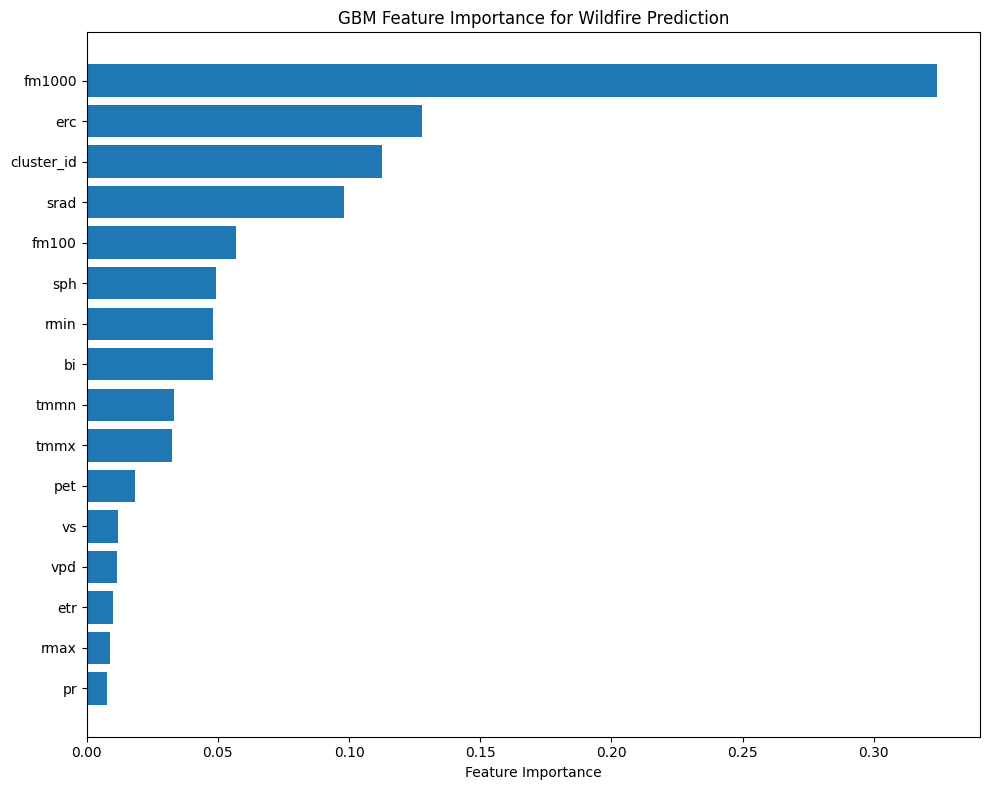

In [16]:
plt.figure(figsize=(10, 8))
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': gbm.feature_importances_
}).sort_values('importance', ascending=True)

plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Feature Importance')
plt.title('GBM Feature Importance for Wildfire Prediction')
plt.tight_layout()
plt.show()

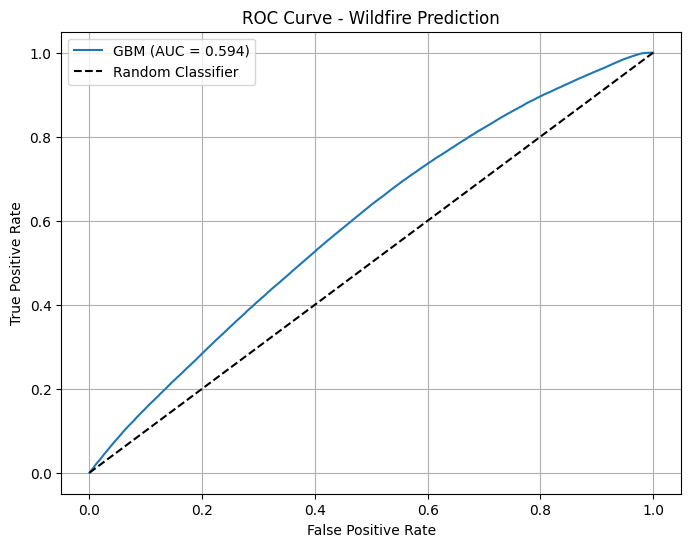

In [17]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'GBM (AUC = {auc_roc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Wildfire Prediction')
plt.legend()
plt.grid(True)
plt.show()

In [18]:
joblib.dump(gbm, 'wildfire_gbm_model.pkl')

['wildfire_gbm_model.pkl']